In [ ]:
!pip install -U --q langchain-community tiktoken langchain-openai langchainhub chromadb langchain langgraph langchain-text-splitters

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.4/120.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.9/178.9 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203

### **이미지가 포함된 리포트 생성그래프 만들기**

In [ ]:
!pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 5.2 MB/s eta 0:00:00


#### **API 키 설정** ####

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# import os
# os.environ['OPENAI_API_KEY'] = "YOUR_OPENAI_API_KEY"
# os.environ['TAVILY_API_KEY'] = "YOUR_TAVILY_API_KEY"

import os
import warnings
warnings.filterwarnings('ignore')

from google.colab import userdata
os.environ['OPENAI_API_KEY'] = userdata.get('kosa')
os.environ['TAVILY_API_KEY'] = userdata.get('tavily')

#### **Graph State 설정** ####

In [ ]:
from typing import Annotated, TypedDict, List, Dict, Sequence
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage

# State definition
class State(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    # add_message 통해 message 지속 누적
    outline: Dict[str, str]   # 목차
    current_section: int      # 현재 섹션 위치
    section_content: str      # 현재 섹션에서 생성된 글
    section_image: str        # 현재 섹션에서 생성된 이미지
    image_prompt: str         # 이미지 생성 프롬프트
    total_sections: int       # 사용자에게 입력받은 전체 몇 개의 섹션을 만들지 결정
    full_report: List[Dict[str, str]]  # 모든 보고서 내용 받아 리포트 작성

# Graph builder initialization
graph_builder = StateGraph(State)

#### **웹 검색 도구 정의** ####

In [ ]:
from langchain_community.tools.tavily_search import TavilySearchResults

search = TavilySearchResults(max_results=3)

/tmp/ipykernel_2398/1418412009.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search = TavilySearchResults(max_results=3)


#### **개요 작성 에이전트 설정** ####

개요를 담을 Data model 선언

In [ ]:
from pydantic import BaseModel, Field, create_model

# create_model은 동적으로 모델을 생성하는 함수
# 사용자로부터 입력받은 전체 섹션 수에 따라 Data model의 key와 value를 정의하기 위한 함수
# create_model 함수는 Pydantic Data model의 이름과 key:value 값을 기반으로 동적인 Data model을 만들 수 있게 보조
def create_outline_model(section_count: int):
    fields = {f"section{i}":
              (str, Field(description=f"Title for section {i}")) for i in range(1, section_count + 1)}
    return create_model("DynamicOutline", **fields)

# section_count 정수형 인자 >> 사용자가 입력한 섹션의 총 개수
# 딕셔너리 컴프리헨션을 사용하여 섹션 수만큼 필드를 생성
# **fields fields 딕셔너리의 키-값 쌍을 키워드 인자로 전달

In [ ]:
fields = {f"section{i}":
              (str, Field(description=f"Title for section {i}")) for i in range(1, 3 + 1)}

DynamicOutline = create_model("DynamicOutline", **fields)

for key, value in DynamicOutline.model_fields.items():
    print(f"key:{key}\n")
    print(f"value:{value}\n")


key:section1

value:annotation=str required=True description='Title for section 1'

key:section2

value:annotation=str required=True description='Title for section 2'

key:section3

value:annotation=str required=True description='Title for section 3'



In [ ]:
DynamicOutline = create_outline_model(5)
for key, value in DynamicOutline.model_fields.items():
    print(f"key:{key}\n")
    print(f"value:{value}\n")

key:section1

value:annotation=str required=True description='Title for section 1'

key:section2

value:annotation=str required=True description='Title for section 2'

key:section3

value:annotation=str required=True description='Title for section 3'

key:section4

value:annotation=str required=True description='Title for section 4'

key:section5

value:annotation=str required=True description='Title for section 5'



In [ ]:
# Outline generation node
def outline_generator(state: State):
    DynamicOutline = create_outline_model(state["total_sections"])
    outline_parser = JsonOutputParser(pydantic_object=DynamicOutline)

    outline_prompt = PromptTemplate(
        template="""
        Create an outline for a detailed report with exactly {section_count} main sections.
        {format_instructions}
        The topic is: {topic}
        """,
        input_variables=["section_count", "topic"],
        partial_variables={"format_instructions": outline_parser.get_format_instructions()},
    )

    chain = outline_prompt | llm | outline_parser

    outline = chain.invoke({
        "section_count": state["total_sections"],
        "topic": state["messages"][-1].content
        # 가장 최근의 받은 메시지 >> 사용자가 입력한 메시지
    })
    return {"outline": outline}

#### **이미지 생성 에이전트 설정** ####

In [ ]:
from openai import OpenAI
from langchain_core.tools import tool

client = OpenAI()

# 이미지 생성
def generate_image(prompt):
    """Generate an image using DALL-E based on the given prompt."""
    response = client.images.generate(
        model="gpt-image-1",
        prompt=prompt,
        size="1024x1024", # 단위: pixel
        quality="standard",
        n=1
    )
    return response.data[0].url
    # data의 첫번째 값의 url 가져옴


def image_generator(state: State):

    prompt_template = PromptTemplate(
        template="""
        Based on the following section content, create a prompt for generating an infographic that represents this section.

        Section content:

        {section_content}

        Image generation prompt(under 500 characters):""",
        input_variables=["section_content"],
    )

    image_prompt = llm.invoke(prompt_template.format(section_content=state["section_content"]))
    image_url = generate_image(image_prompt.content)

    current_section = {
        "title": state['outline'][f"section{state['current_section']}"],
        "content": state['section_content'],
        "image_url": image_url,
        "image_prompt": image_prompt.content if isinstance(image_prompt, AIMessage) else image_prompt
    }

    updated_full_report = state.get("full_report", []) + [current_section]

    print(f"Completed section {state['current_section']} of {state['total_sections']}")

    return {
        "image_prompt": image_prompt.content if isinstance(image_prompt, AIMessage) else image_prompt,
        "section_image": image_url,
        "current_section": state["current_section"] + 1,
         # 현재 섹션에 1 더해서, 다음 섹션으로 넘거가게 설정
        "full_report": updated_full_report
    }


In [ ]:
from openai import OpenAI
from langchain_core.messages import AIMessage
from langchain_core.prompts import PromptTemplate
import base64
import uuid
import os

client = OpenAI()


# 이미지 생성
def generate_image(prompt):
    """Generate an image using gpt-image-1 based on the given prompt."""

    response = client.images.generate(
        model="gpt-image-1",
        prompt=prompt,
        size="1024x1024",
        quality="medium",
        n=1
    )

    image_base64 = response.data[0].b64_json
    image_bytes = base64.b64decode(image_base64)

    os.makedirs("generated_images", exist_ok=True)

    image_path = f"generated_images/{uuid.uuid4()}.png"

    with open(image_path, "wb") as f:
        f.write(image_bytes)

    return image_path


def image_generator(state: State):

    prompt_template = PromptTemplate(
        template="""
        Based on the following section content, create a prompt for generating an infographic that represents this section.

        Section content:
        {section_content}

        Image generation prompt under 500 characters:
        """,
        input_variables=["section_content"],
    )

    image_prompt = llm.invoke(
        prompt_template.format(
            section_content=state["section_content"]
        )
    )

    image_prompt_text = (
        image_prompt.content
        if isinstance(image_prompt, AIMessage)
        else str(image_prompt)
    )

    image_path = generate_image(image_prompt_text)

    current_section = {
        "title": state["outline"][f"section{state['current_section']}"],
        "content": state["section_content"],
        "image_url": image_path,
        "image_prompt": image_prompt_text
    }

    updated_full_report = state.get("full_report", []) + [current_section]

    print(f"Completed section {state['current_section']} of {state['total_sections']}")

    return {
        "image_prompt": image_prompt_text,
        "section_image": image_path,
        "current_section": state["current_section"] + 1,
        "full_report": updated_full_report
    }

#### **LLM 설정** ####

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")

#### **컨텐츠 작성 에이전트 설정** ####

In [ ]:
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.prompts import PromptTemplate

def contents_writer(state: State):
    if "error" in state:
        return {"messages": [AIMessage(content=f"An error occurred: {state['error']}")]}

    # 현재 섹션이 전체 섹션보다 크면 >> 리포트 완성
    if state["current_section"] > state["total_sections"]:
        return {"messages": [AIMessage(content="Report completed.")]}

    current_section_key = f"section{state['current_section']}"
    current_topic = state["outline"][current_section_key]
    search_results = search.invoke(current_topic)

    previous_sections_content = []
    for i in range(1, state['current_section']):
        section_key = f"section{i}"
        if section_key in state["section_content"]:
            previous_sections_content.append(f"""
            Section {i}:
            {state['outline'][section_key]}
            {state['section_content'][section_key]}
            """)

    previous_sections = "\n\n".join(previous_sections_content)

    section_prompt = PromptTemplate(
        template="""
        Write a detailed section for the topic: {topic}.

        Use the following search results for information: {search_results}

        Previous sections:
        {previous_sections}
        Write only the content for this section,
        do not include any image prompts or suggestions.
        Detailed statistics or information is needed,
        so you should include collected information from search result.""",
        input_variables=["topic", "search_results", "previous_sections"],
    )
    section_content = llm.invoke(section_prompt.format(
        topic=current_topic,
        search_results=search_results,
        previous_sections=previous_sections
    ))

    return {
        "section_content": section_content.content,
        "current_section": state["current_section"]
    }


#### **워드 생성 에이전트 설정** ####

In [ ]:
from docx import Document
from docx.shared import Inches
import requests
from io import BytesIO

def report_generator(state: State):
    doc = Document()
    doc.add_heading(f"Report: {state['messages'][0].content}", 0)
    # 제목 사용자가 처음 입력한 메시지(['messages'[0]])

    for section in state['full_report']:
        doc.add_heading(section['title'], level=1)
        doc.add_paragraph(section['content'])

        # 이미지 추가
        if section['image_url'] != "Image generation failed":
            try:
                response = requests.get(section['image_url']) # 이미지 가져오기(image_url)
                image = BytesIO(response.content)             # 가져온 이미지 decoding
                doc.add_picture(image, width=Inches(6))       # 이미지 추가
                doc.add_paragraph(f"Image prompt: {section['image_prompt']}")
            except Exception as e:
                doc.add_paragraph(f"Failed to add image: {str(e)}")

        doc.add_page_break()
        # 다음 페이지로 넘어가게 정지조건 설정

    # 보고서 저장
    filename = f"report_{state['messages'][0].content}.docx".replace(" ", "_")
    doc.save(filename)

    return {
        "messages": [AIMessage(content=f"Report finalized and saved as {filename}.")],
        "report_file": filename
    }


#### **그래프 구축** ####

In [ ]:
# Add nodes
graph_builder.add_node("outline_generator", outline_generator)
graph_builder.add_node("contents_writer", contents_writer)
graph_builder.add_node("image_generator", image_generator)
graph_builder.add_node("report_generator", report_generator)

# Add edges
graph_builder.add_edge(START, "outline_generator")
graph_builder.add_edge("outline_generator", "contents_writer")
graph_builder.add_edge("contents_writer", "image_generator")
graph_builder.add_edge("report_generator", END)

# Add conditional edges(분기 조건)
def should_continue_writing(state: State):
    if state["current_section"] <= state["total_sections"]:
        return "write_section"
    else:
        return "finalize_report"

graph_builder.add_conditional_edges(
    "image_generator",
    should_continue_writing,
    {
        "write_section": "contents_writer",
        "finalize_report": "report_generator"
    }
)

# Compile graph
graph = graph_builder.compile()

#### **그래프 시각화**

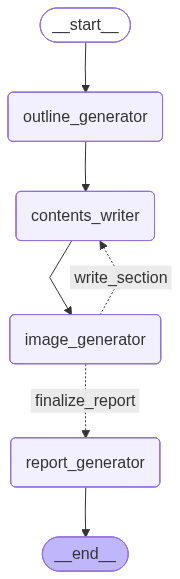

In [ ]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

#### **그래프 실행**

In [ ]:
import os

current_directory = os.getcwd()
print(f"현재 작업 디렉토리: {current_directory}")

현재 작업 디렉토리: /content


In [ ]:
from langchain_core.messages import HumanMessage

# 사용자 입력 받기
topic = input("보고서 주제를 입력하세요: ")
total_sections = int(input("생성할 섹션의 수를 입력하세요: "))

# 초기 상태 설정
initial_state = {
    "messages": [HumanMessage(content=topic)],
    "total_sections": total_sections,
    "current_section": 1,
}

# 그래프 실행
for chunk in graph.stream(initial_state,stream_mode="update"):
    print(chunk)

print("\n=== 보고서 생성 완료 ===")

보고서 주제를 입력하세요: 피지컬 AI
생성할 섹션의 수를 입력하세요: 3
Completed section 1 of 3
Completed section 2 of 3
Completed section 3 of 3

=== 보고서 생성 완료 ===


In [ ]:
# eos